# A cross-sectional ML alpha signal — and how to evaluate it without fooling yourself

Predicting absolute market returns is mostly hopeless. Predicting the **cross-sectional ranking** — which names will out- or under-perform their peers next month — is tractable, and it's what most equity ML signals actually do.

The model here (gradient-boosted trees) is deliberately boring. The parts worth your attention are the *evaluation discipline*:

- features standardised **per day** (cross-sectionally), so we're learning relative, not absolute, signals;
- a forward-return label joined **without lookahead**;
- **walk-forward** folds with a **purge gap** equal to the label horizon, so overlapping forward windows can't leak across the train/test boundary;
- scoring by **information coefficient** (rank correlation), and then the real test — does a long/short portfolio built on the predictions actually separate, monotonically, by predicted quantile?

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (11, 4), 'axes.grid': True, 'grid.alpha': 0.3})

from quantlab.data.database import MarketDB
from quantlab.features import build_feature_panel, FeatureConfig
from quantlab.models.ml import (make_forward_target, evaluate_cross_sectional_model,
                                walk_forward_predictions)

db = MarketDB.from_config()
long = db.load_long(); px = db.load_prices(field='adj_close')
cfg = FeatureConfig()
panel = build_feature_panel(long, cfg)
print('feature panel:', panel.shape, '| features:', cfg.feature_cols)
panel.head(3)

feature panel: (41856, 9) | features: ['mom_21', 'mom_63', 'mom_126', 'mom_252', 'vol_21', 'zscore_21', 'rsi_14', 'vol_ratio_21', 'ret_1d']


,,mom_21,mom_63,mom_126,mom_252,vol_21,zscore_21,rsi_14,vol_ratio_21,ret_1d
date,symbol,,,,,,,,,
2016-01-04,AAPL,-0.098713,-0.042370,-0.170206,-0.020188,0.248387,-1.227408,34.329655,0.433047,0.000855
2016-01-05,AAPL,-0.114760,-0.071366,-0.193122,-0.016991,0.258184,-1.597379,29.861881,0.225004,-0.025379
2016-01-06,AAPL,-0.167230,-0.095902,-0.187749,-0.036848,0.221867,-1.832158,26.982665,0.418251,-0.019763


## 1. The features, and whether they're redundant

Before modelling, a sanity check: how correlated are the features? Heavily collinear features (e.g. momentum at neighbouring horizons) don't add independent information and can destabilise a linear model — trees handle it more gracefully, but it's still worth *seeing*.

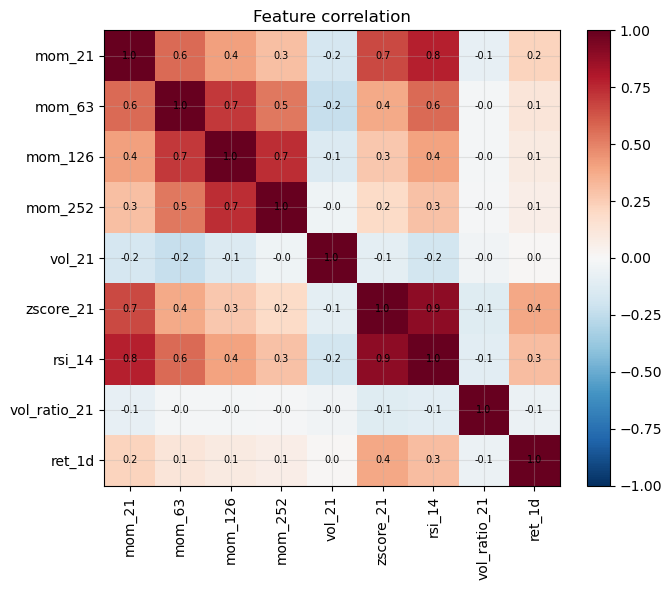

In [2]:
corr = panel[cfg.feature_cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i,j]:.1f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, fraction=0.046); ax.set_title('Feature correlation'); plt.tight_layout()

As expected, the momentum horizons are positively correlated with each other and the short-term reversal (`ret_1d`) sits apart. Nothing is so collinear that it needs dropping for a tree model.

## 2. Walk-forward IC

Now the headline evaluation. The label is the forward 21-day return; the purge gap is 21 days to match.

Mean IC: 0.0373   IC information ratio (mean/std across folds): 1.69


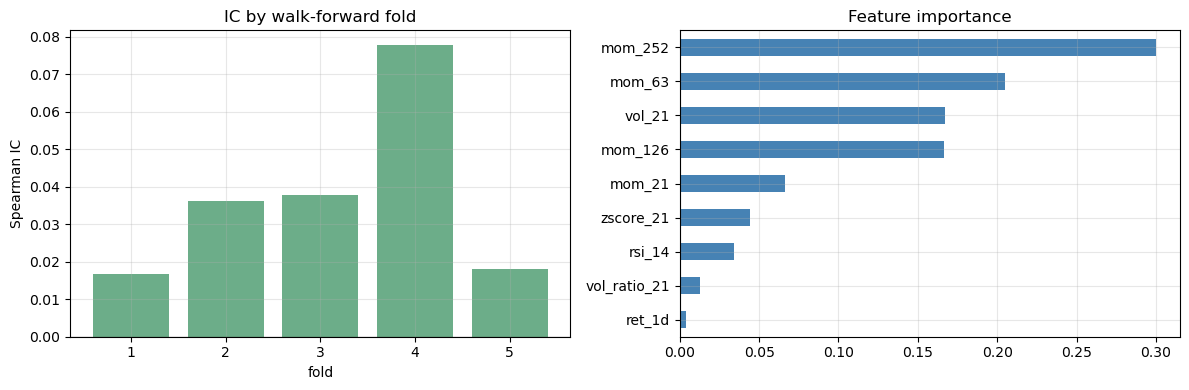

In [3]:
target = make_forward_target(px, horizon=21)
res = evaluate_cross_sectional_model(panel[cfg.feature_cols], target, horizon=21, n_splits=5)
print(f'Mean IC: {res.mean_ic:.4f}   IC information ratio (mean/std across folds): {res.ic_ir:.2f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(range(1, len(res.fold_ic)+1), res.fold_ic, color='seagreen', alpha=0.7)
ax[0].axhline(0, color='k', lw=0.8); ax[0].set(title='IC by walk-forward fold', xlabel='fold', ylabel='Spearman IC')
res.feature_importance.plot.barh(ax=ax[1], color='steelblue'); ax[1].set_title('Feature importance'); ax[1].invert_yaxis()
plt.tight_layout()

A mean IC around 0.03–0.05 that survives walk-forward is a believable equity signal — and the fact that the model leans on the longer momentum horizons is reassuring, because that's a factor with a real economic story (Jegadeesh-Titman), not a data-mined coincidence. A much *larger* IC on this data would worry me more than a small one: it would smell of leakage.

## 3. The real test: do the predictions sort returns?

IC is a correlation. What we actually trade is a portfolio: long the top-ranked names, short the bottom. So I take the out-of-sample predictions, bucket each day's cross-section into quintiles by predicted return, and look at the *realised* forward return of each bucket. If the signal is real, the buckets should line up monotonically and the top-minus-bottom spread should be positive.

Top-minus-bottom quintile spread: 1.09% per 21 days (gross, before costs)


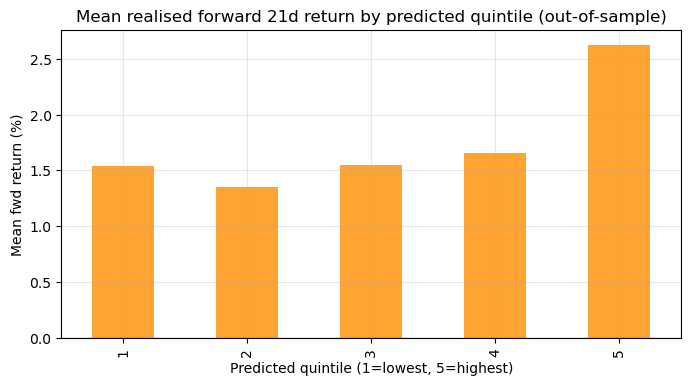

In [4]:
oos = walk_forward_predictions(panel[cfg.feature_cols], target, horizon=21, n_splits=5)
# Rank into 5 buckets within each date, then average realised forward return per bucket.
oos = oos.copy()
oos['quintile'] = oos.groupby(level='date')['prediction'].transform(
    lambda s: pd.qcut(s.rank(method='first'), 5, labels=False) + 1 if s.notna().sum() >= 5 else np.nan)
bucket = oos.dropna(subset=['quintile']).groupby('quintile')['fwd_return'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
(bucket * 100).plot.bar(ax=ax, color='darkorange', alpha=0.8)
ax.set(title='Mean realised forward 21d return by predicted quintile (out-of-sample)',
       xlabel='Predicted quintile (1=lowest, 5=highest)', ylabel='Mean fwd return (%)')
ax.axhline(0, color='k', lw=0.8)
spread = (bucket.loc[5] - bucket.loc[1]) * 100
print(f'Top-minus-bottom quintile spread: {spread:.2f}% per 21 days (gross, before costs)')

## 4. Turning the signal into a tradeable long/short return stream

Finally, form a daily dollar-neutral portfolio from the quintile spread and compound it (gross of costs, for signal-quality purposes — the event-driven backtester is where costs get charged properly). The slope of this curve *is* the signal's economic value.

Gross long-short IR (per-period proxy): 2.85


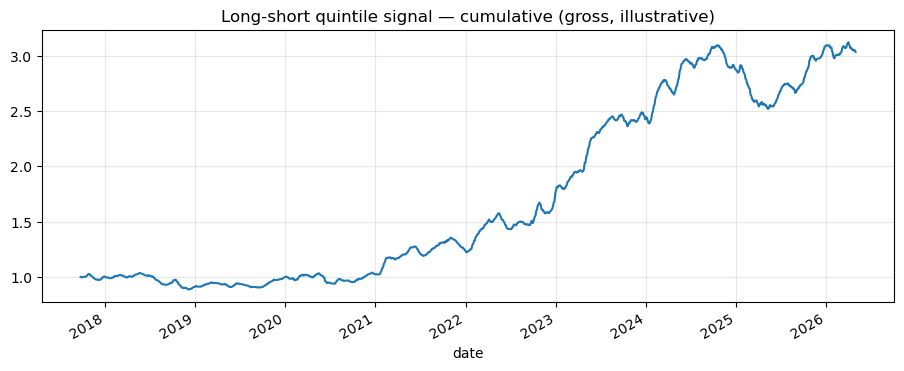

In [5]:
from quantlab.utils import sharpe_ratio
# Long top quintile, short bottom, equal weight, rebalanced each prediction date.
top = oos[oos['quintile'] == 5].groupby(level='date')['fwd_return'].mean()
bot = oos[oos['quintile'] == 1].groupby(level='date')['fwd_return'].mean()
ls = (top - bot).sort_index()
# These are overlapping 21d forward returns sampled daily; scale to a per-day proxy for the curve.
curve = (1 + ls / 21).cumprod()
curve.plot(title='Long-short quintile signal — cumulative (gross, illustrative)')
print(f'Gross long-short IR (per-period proxy): {sharpe_ratio(ls / 21):.2f}')

## Takeaways

- The signal has a small but **stable, monotonic** cross-sectional edge — the quintiles sort in the right order out-of-sample, which is more convincing than the IC number alone.
- It is driven by **economically interpretable** features (multi-horizon momentum), not opaque interactions — that's a point in its favour, not against.
- The gross long-short curve looks fine; the honest caveat is that this is **before** transaction costs and at a horizon with heavy overlap. The real test is feeding the ranks into `quantlab.backtest` with the cost model on — which is exactly the bridge from this notebook to a deployable strategy.

**Next steps the repo supports:** neutralise the signal against sector/market beta, add the macro features from `quantlab.models.macro_forecast`, and compare the GBM against the PyTorch model in `quantlab.models.deep`.